ROOT = /data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation
CelebA images found = 202599
Personal images found = 0
Saved raw-data audit to: /data/Sajjan_Singh/gen/gen_scaffold/realistic_face_generation/reports/notes/notebook03_raw_data_audit.json


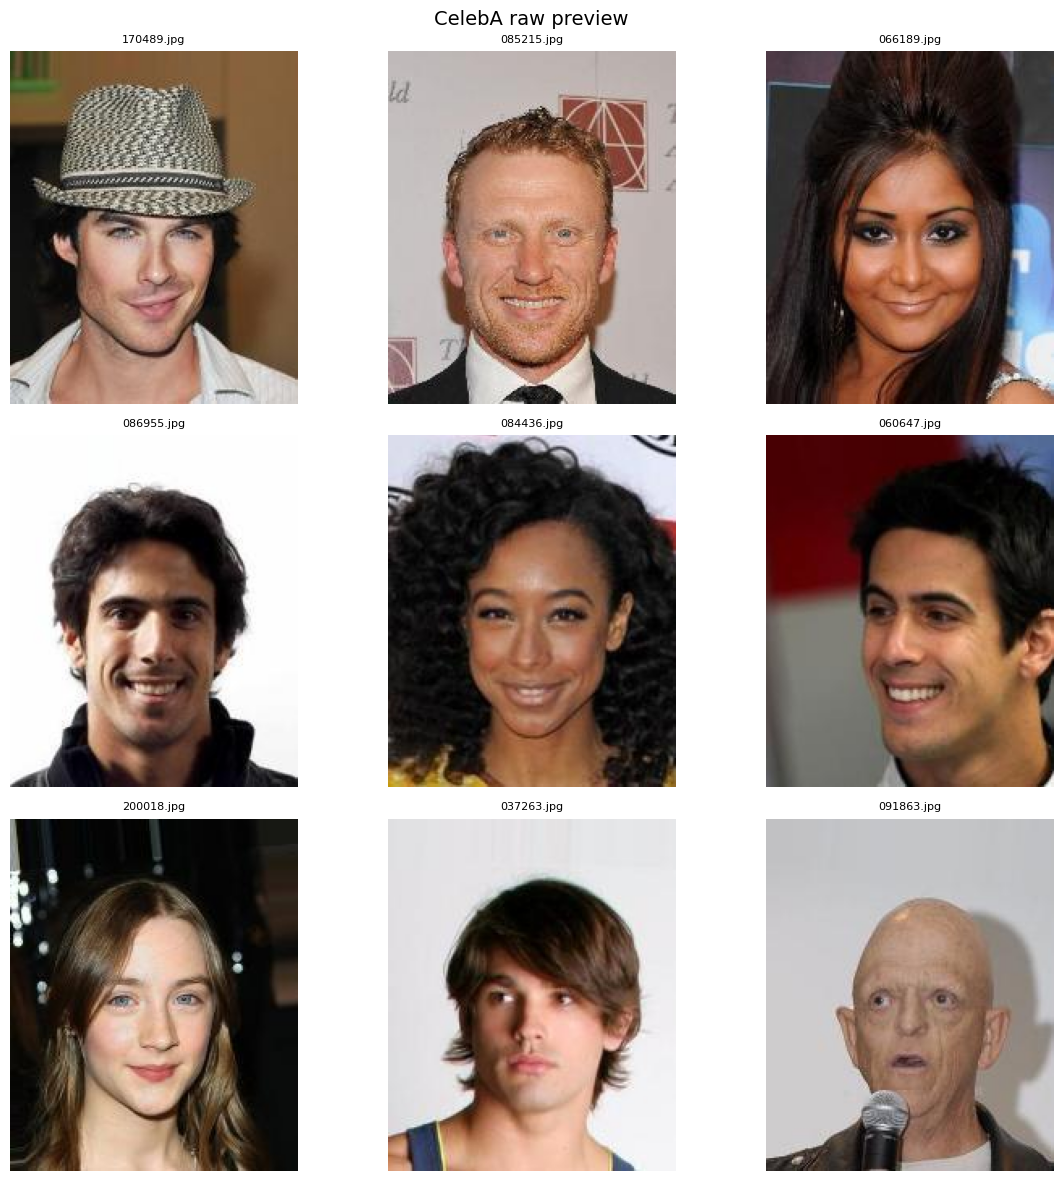

[INFO] You have not added personal images yet. Add them later to data/raw/personal_raw

Notebook 03 complete.
We are intentionally skipping CelebA preprocessing here.
Notebook 04 will build the 256x256 StyleGAN3 ZIP directly from data/raw/celeba.


In [6]:
from pathlib import Path
import os, json, random, math
from datetime import datetime
from PIL import Image, ImageFile
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = True

# =========================================================
# SETTINGS
# =========================================================
MAX_PREVIEW = 9

# =========================================================
# PATHS
# =========================================================
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

raw_celeba = ROOT / "data" / "raw" / "celeba"
raw_personal = ROOT / "data" / "raw" / "personal_raw"
audit_dir = ROOT / "reports" / "notes"
audit_dir.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def list_images(folder: Path):
    if not folder.exists():
        return []
    return sorted([p for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])

def preview_grid(paths, title, n=9):
    paths = paths[:n]
    if len(paths) == 0:
        print(f"[WARN] No images to preview for {title}")
        return
    cols = min(3, len(paths))
    rows = math.ceil(len(paths) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    elif cols == 1:
        axes = [[ax] for ax in axes]

    k = 0
    for r in range(rows):
        for c in range(cols):
            ax = axes[r][c]
            if k < len(paths):
                try:
                    img = Image.open(paths[k]).convert("RGB")
                    ax.imshow(img)
                    ax.set_title(paths[k].name[:28], fontsize=8)
                except Exception as e:
                    ax.text(0.5, 0.5, f"Bad image\n{e}", ha="center", va="center")
                ax.axis("off")
            else:
                ax.axis("off")
            k += 1
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def sample_sizes(paths, sample_n=25):
    sizes = []
    bad = []
    for p in paths[:sample_n]:
        try:
            with Image.open(p) as im:
                sizes.append(im.size)
        except Exception as e:
            bad.append({"file": str(p), "error": str(e)})
    return sizes, bad

celeba_imgs = list_images(raw_celeba)
personal_imgs = list_images(raw_personal)

summary = {
    "time": datetime.now().isoformat(),
    "root": str(ROOT),
    "raw_celeba_dir": str(raw_celeba),
    "raw_personal_dir": str(raw_personal),
    "num_celeba_images": len(celeba_imgs),
    "num_personal_images": len(personal_imgs),
}

print("ROOT =", ROOT)
print("CelebA images found =", len(celeba_imgs))
print("Personal images found =", len(personal_imgs))

assert len(celeba_imgs) > 0, f"No images found in {raw_celeba}. Notebook 02 must finish first."

celeba_sizes, celeba_bad = sample_sizes(celeba_imgs, sample_n=50)
personal_sizes, personal_bad = sample_sizes(personal_imgs, sample_n=20) if len(personal_imgs) > 0 else ([], [])

summary["celeba_sample_sizes"] = celeba_sizes[:10]
summary["celeba_bad_files"] = celeba_bad[:10]
summary["personal_sample_sizes"] = personal_sizes[:10]
summary["personal_bad_files"] = personal_bad[:10]

audit_path = audit_dir / "notebook03_raw_data_audit.json"
audit_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print(f"Saved raw-data audit to: {audit_path}")

preview_grid(random.sample(celeba_imgs, min(MAX_PREVIEW, len(celeba_imgs))), "CelebA raw preview", n=MAX_PREVIEW)

if len(personal_imgs) > 0:
    preview_grid(personal_imgs, "Personal raw preview", n=min(MAX_PREVIEW, len(personal_imgs)))
else:
    print("[INFO] You have not added personal images yet. Add them later to data/raw/personal_raw")

print("\nNotebook 03 complete.")
print("We are intentionally skipping CelebA preprocessing here.")
print("Notebook 04 will build the 256x256 StyleGAN3 ZIP directly from data/raw/celeba.")